<a href="https://colab.research.google.com/github/aryakamat01-sketch/pbs-generic-erosion/blob/main/pbs_generic_erosion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
print(pd.__version__)

2.2.3


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Data

PBS and RPBS Date of Supply supplementary reports, July 2022 – June 2026
(48 months). Source: Australian Government Department of Health, Disability
and Ageing, www.pbs.gov.au

These supplementary reports include dispensing pharmacy type but exclude
Section 100 special arrangements, so this analysis covers general community
supply only.

In [3]:
import glob

files = sorted(glob.glob('/content/drive/MyDrive/pbs-data/dos-*.csv'))
print(files)

frames = [pd.read_csv(f) for f in files]
raw = pd.concat(frames, ignore_index=True)
print(raw.shape)

['/content/drive/MyDrive/pbs-data/dos-jul-2022-to-jun-2023-phrmcy-type.csv', '/content/drive/MyDrive/pbs-data/dos-jul-2023-to-jun-2024-phrmcy-type.csv', '/content/drive/MyDrive/pbs-data/dos-jul-2024-to-jun-2025-phrmcy-type.csv', '/content/drive/MyDrive/pbs-data/dos-jul-2025-to-jun-2026-phrmcy-type.csv']
(1490524, 12)


## Joining drug names

The supplementary reports contain ITEM_CODE but no drug name, so the PBS
item-to-drug mapping file is required. The file is not UTF-8 encoded and
needs Latin-1.

192 of 789,577 rows found no matching drug name (0.02%) — most likely
historical item codes or the 99999Z placeholder used for unlisted RPBS items.
Left as-is rather than dropped.

In [4]:
drug_map = pd.read_csv('/content/drive/MyDrive/pbs-data/pbs-item-drug-map.csv', encoding='latin-1')
print(drug_map.shape)
drug_map.head()

(12162, 4)


,ITEM_CODE,DRUG_NAME,FORM/STRENGTH,ATC5_Code
0,00000A,MISSING ITEM CODE,Missing Item Code,Z
1,00013Q,EXTEMPORANEOUSLY PREPARED,Creams,Z
2,00015T,EXTEMPORANEOUSLY PREPARED,Ear drops,Z
3,00016W,ELIXIRS,Generic term,Z
4,00019B,EXTEMPORANEOUSLY PREPARED,Eye drops containing cocaine hcl,Z


## Scope decisions

**Above co-payment only.** Under co-payment scripts record a zero government
contribution, so total cost is zero and cost per script would compute as $0.
Including them would fabricate price collapses that never happened.
This excludes roughly 16% of rows.

**S90 community pharmacies only.** Excludes public and private hospital
dispensing (S94) and approved medical practitioners (S92), where pricing
arrangements differ. Retail generic competition is the question here, so
community pharmacy is the right population.

In [5]:
work = raw[(raw['SCRIPT_TYPE'] == 'ABOVE CO-PAYMENT') & (raw['PHRMCY_TYPE'] == 'S90')].copy()
work = work.merge(drug_map, on='ITEM_CODE', how='left')

print(work.shape)
print(work['DRUG_NAME'].isna().sum())

(789577, 15)
192


## Key metric: cost per script

cost_per_script = TOTAL_COST / PRESCRIPTIONS

**Important limitation.** TOTAL_COST includes the ex-manufacturer price plus
wholesale and retail mark-up, the dispensing fee and other fees. The
dispensing fee is roughly fixed per script, which puts a floor under cost per
script — the observed minimum across the dataset is $6.19.

This means measured price erosion systematically **understates** true
manufacturer price erosion, and the understatement is worst for the cheapest
drugs. A generic whose manufacturer price falls 90% may show far less
erosion here.

TOTAL_COST also excludes brand premiums paid by patients, so any premium
an originator charges after generic entry is invisible in this data.

In [6]:
work['date'] = pd.to_datetime(work['MONTH_OF_SUPPLY'], format='%Y%m')
work['cost_per_script'] = work['TOTAL_COST'] / work['PRESCRIPTIONS']

print(work['date'].min(), work['date'].max())
print(work['date'].nunique())
print(work['cost_per_script'].describe())

2022-07-01 00:00:00 2026-06-01 00:00:00
48
count    789577.000000
mean        569.329926
std        1939.327600
min           6.190000
25%          22.560000
50%          45.680000
75%         225.980000
max      201042.960000
Name: cost_per_script, dtype: float64


## Completeness check

The Explanatory Notes warn that recent months are less complete and that the
report "should not be used to analyse the recent trends". Checking total
prescriptions for the final six months: values range 17.3M–20.0M with the
last month among the highest, showing no sign of truncation. All 48 months
retained.

In [7]:
work.groupby('date')['PRESCRIPTIONS'].sum().tail(6)

,PRESCRIPTIONS
date,
2026-01-01,17255493
2026-02-01,17553355
2026-03-01,19947341
2026-04-01,18935944
2026-05-01,19676963
2026-06-01,19992133


## Aggregating to item level

Collapsing patient categories to give one row per item code per month.

Working at ITEM_CODE rather than DRUG_NAME is deliberate: a single drug
name covers multiple strengths and pack sizes at genuinely different
prices, so aggregating by name would let shifts in the product mix appear
as price movement. Item code is the level at which PBS pricing actually
operates, so a change there is a real price change.

In [8]:
monthly = (work.groupby(['ITEM_CODE', 'date'])
               .agg(scripts=('PRESCRIPTIONS', 'sum'),
                    cost=('TOTAL_COST', 'sum'))
               .reset_index())

monthly['cost_per_script'] = monthly['cost'] / monthly['scripts']

labels = drug_map[['ITEM_CODE', 'DRUG_NAME', 'FORM/STRENGTH']]
monthly = monthly.merge(labels, on='ITEM_CODE', how='left')

print(monthly.shape)
monthly.head()

(195389, 7)


,ITEM_CODE,date,scripts,cost,cost_per_script,DRUG_NAME,FORM/STRENGTH
0,00000B,2022-07-01,1747,79710.93,45.627321,NaN,NaN
1,00000B,2022-08-01,1910,117560.95,61.550236,NaN,NaN
2,00000B,2022-09-01,1730,86583.38,50.048197,NaN,NaN
3,00000B,2022-10-01,1714,97024.92,56.607305,NaN,NaN
4,00000B,2022-11-01,1721,119127.70,69.220046,NaN,NaN


## Selecting candidates

Two filters:

**Present in all 48 months.** Before-and-after comparison is impossible for
an item that appeared or disappeared partway through the window.

**More than 100,000 total prescriptions.** The median row in the raw data
has only 31 prescriptions, and low-volume items produce unstable monthly
price estimates. This threshold keeps the analysis to items where cost per
script is a reliable measure.

This leaves 885 candidates from 5,479 items.

In [9]:
totals = (monthly.groupby('ITEM_CODE')
                 .agg(total_scripts=('scripts', 'sum'),
                      months=('date', 'nunique'))
                 .reset_index())

print(len(totals))
print((totals['months'] == 48).sum())

candidates = totals[(totals['months'] == 48) & (totals['total_scripts'] > 100000)]
print(len(candidates))

5479
2706
885


In [10]:
cand = monthly[monthly['ITEM_CODE'].isin(candidates['ITEM_CODE'])].copy()
cand = cand.sort_values(['ITEM_CODE', 'date'])

first6 = cand.groupby('ITEM_CODE').head(6).groupby('ITEM_CODE')['cost_per_script'].mean()
last6  = cand.groupby('ITEM_CODE').tail(6).groupby('ITEM_CODE')['cost_per_script'].mean()

change = pd.DataFrame({'start_price': first6, 'end_price': last6}).reset_index()
change['pct_change'] = (change['end_price'] - change['start_price']) / change['start_price'] * 100

change = change.merge(labels, on='ITEM_CODE', how='left')
change = change.merge(candidates[['ITEM_CODE', 'total_scripts']], on='ITEM_CODE')

change.sort_values('pct_change').head(20)

,ITEM_CODE,start_price,end_price,pct_change,DRUG_NAME,FORM/STRENGTH,total_scripts
786,11178H,7774.626147,1569.786520,-79.808849,USTEKINUMAB,Injection 45 mg in 0.5 mL,159190
851,12152N,1142.484535,444.794342,-61.067802,AFLIBERCEPT,Solution for intravitreal injection 3.6 mg in ...,265533
852,12153P,1284.982918,501.336102,-60.984999,AFLIBERCEPT,Solution for intravitreal injection 3.6 mg in ...,115318
313,05262Y,2026.686256,794.078229,-60.818887,FINGOLIMOD,Capsule 500 micrograms (as hydrochloride),140767
109,01952R,74.205607,29.428808,-60.341531,RASAGILINE,Tablet 1 mg (as mesilate),320508
688,10104T,293.443592,124.065189,-57.720941,FERRIC CARBOXYMALTOSE,Injection 500 mg (iron) in 10 mL,1210719
825,11702X,298.910069,127.078392,-57.486078,FERRIC CARBOXYMALTOSE,Injection 1000 mg (iron) in 20 mL,618175
729,10529E,107.574709,49.961565,-53.556402,LURASIDONE,Tablet containing lurasidone hydrochloride 80 mg,216858
722,10486X,98.802262,46.052259,-53.389469,LISDEXAMFETAMINE,Capsule containing lisdexamfetamine dimesilate...,1683375
723,10492F,98.765812,46.042734,-53.381911,LISDEXAMFETAMINE,Capsule containing lisdexamfetamine dimesilate...,1049230


## Two different patterns

Ranking candidates by four-year price change and plotting the largest
fallers reveals two distinct shapes that the summary table cannot
distinguish:

**Step changes.** Lisdexamfetamine, sacubitril + valsartan and ustekinumab
hold a flat price for years, then drop once and stay down. Lisdexamfetamine
falls from roughly \$100 to \$46 in a single month in late 2025;
ustekinumab from about \$7,800 to \$1,570 in mid-2025. This is the signature
of competitive entry.

**Staircases.** Rasagiline and fingolimod decline through four or five
smaller steps spread across the whole window. Total decline is comparable,
but the mechanism is different — this pattern is consistent with scheduled
statutory price reductions rather than a competitor arriving.

Both groups show a similar percentage fall, so magnitude alone cannot
separate them. The shape of the decline is what distinguishes competitive
entry from regulated price reduction, and the next step is to classify all
885 candidates on that basis.

Note that ustekinumab and aflibercept are biologics — their competitors are
biosimilars rather than small-molecule generics.

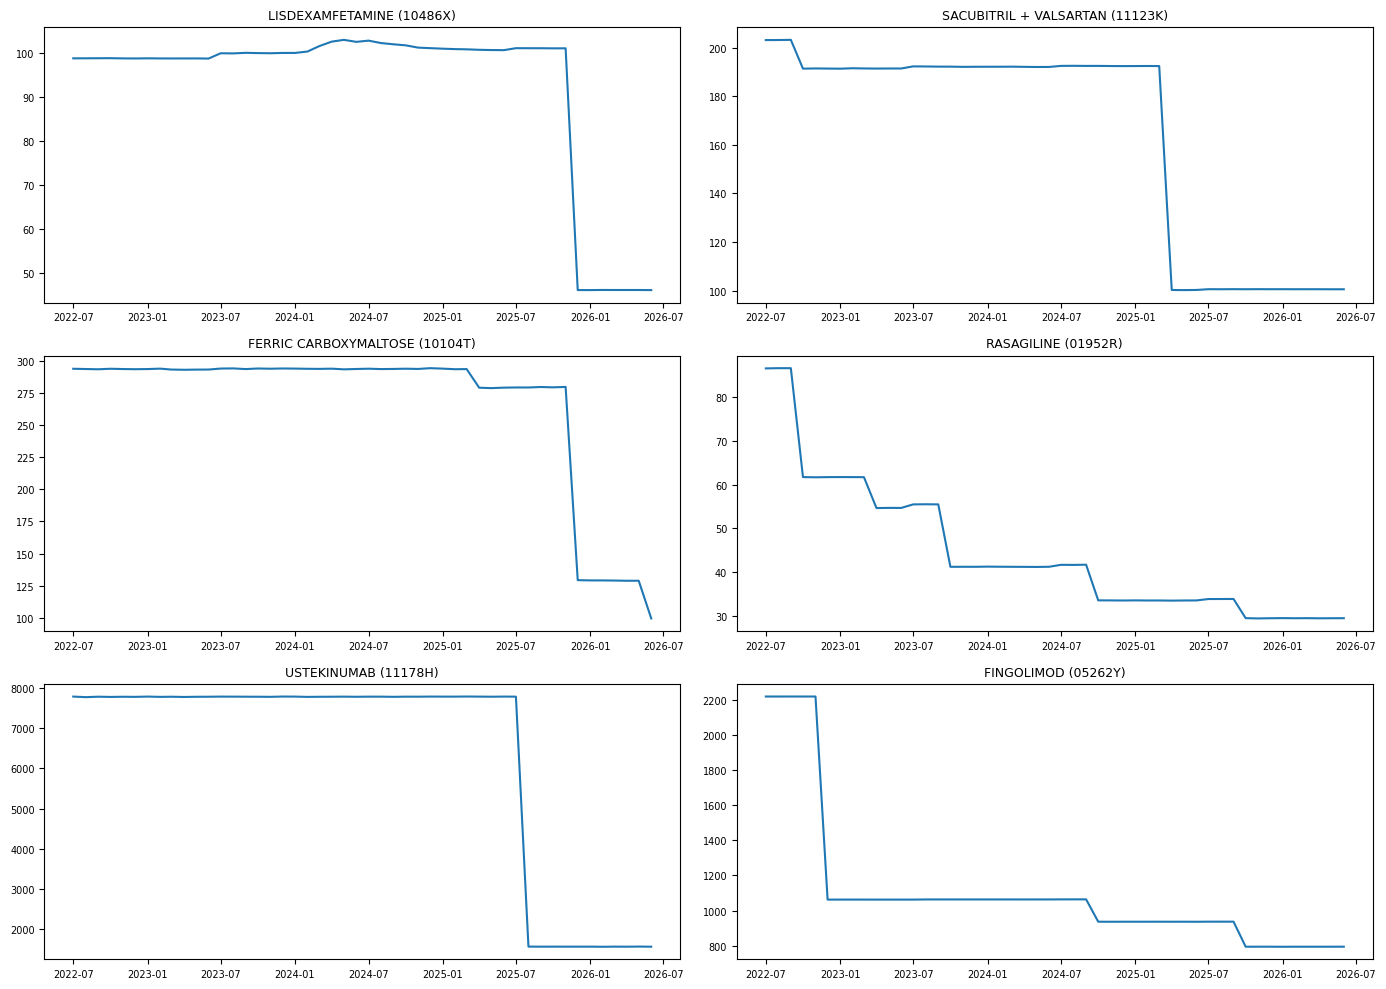

In [11]:
import matplotlib.pyplot as plt

picks = ['10486X', '11123K', '10104T', '01952R', '11178H', '05262Y']

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
for ax, code in zip(axes.flat, picks):
    d = monthly[monthly['ITEM_CODE'] == code].sort_values('date')
    ax.plot(d['date'], d['cost_per_script'])
    ax.set_title(f"{d['DRUG_NAME'].iloc[0]} ({code})", fontsize=9)
    ax.tick_params(labelsize=7)
plt.tight_layout()
plt.show()

Six separate lisdexamfetamine item codes, covering different strengths,
all fall between 53.3% and 53.4%. Independent items moving within a tenth
of a percent of each other indicates a single pricing event affecting every
presentation of the molecule simultaneously, rather than noise.